### Regression Trees

<h4>Introduction</h4>
The dataset used in this exercise session is a subset of the publicly available <a><href='https://www1.nyc.gov/site/tlc/about/tlc-trip-record-data.page'>TLC Dataset</a> (all rights reserved by Taxi & Limousine Commission (TLC), City of New York). The prediction of the tip amount can be modeled as a regression problem. To train the model you can use part of the input dataset and the remaining data can be used to assess the quality of the trained model.
    <br>
</div>

In [2]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [6]:
# read the input data
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
raw_data = pd.read_csv(url)
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


Each row in the dataset represents a taxi trip. As shown above, each row has 13 variables. One of the variables is `tip_amount` which will be the target variable. Your objective will be to train a model that uses the other variables to predict the value of the `tip_amount` variable.

To understand the dataset a little better, let us plot the correlation of the target variable against the input variables.



<Axes: >

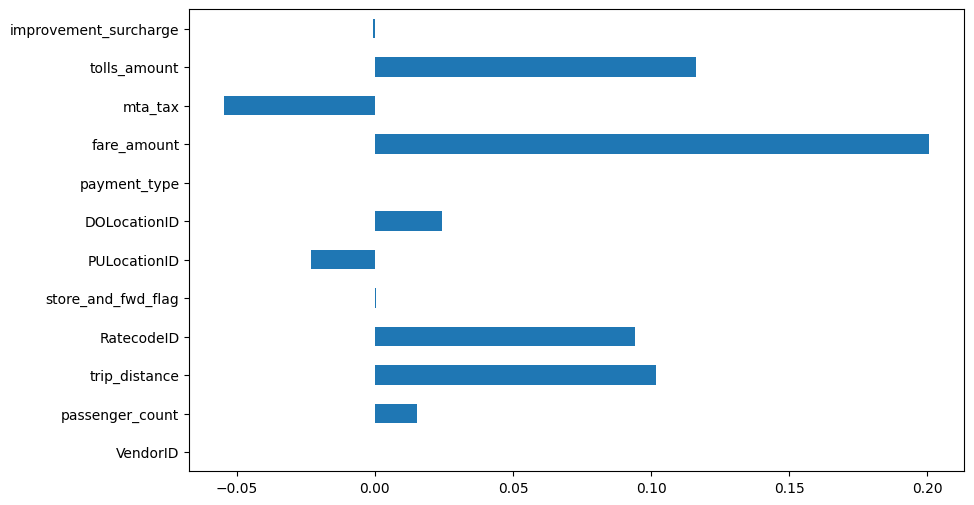

In [7]:
corr_values = raw_data.corr()['tip_amount'].drop('tip_amount')
corr_values.plot(kind='barh', figsize=(10,6))

This shows us that the input features `payment_type`, `VendorID`, `store_and_fwd_flag` and `improvement_surcharge` have little to no correlation with the target variable.


##### Data processing
You will now prepare the data for training by applying normalization to the input features.


In [8]:
# extract the labels from the df
y = raw_data[['tip_amount']].values.astype('float32')

# drop the target variable from the feature matrx
proc_data = raw_data.drop(['tip_amount'], axis=1)

# get feature matrix for training
X = proc_data.values

# normalize the feature matrix
X = normalize(X, axis=1, norm='l1', copy=False)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Decision Tree Regressor model with scikit-learn
Regression Trees are implemented using `DecisionTreeRegressor`.

The important parameters of the model are:

`criterion`: The function used to measure error, we use 'squared_error'.

`max_depth` - The maximum depth the tree is allowed to take; we use 8.

In [10]:
# import the Decision Tree Regression Model from scikit-learn
from sklearn.tree import DecisionTreeRegressor

# for reproducible output across multiple function calls, set random_state to a given integer value
dt_reg = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=8, 
                               random_state=35)

In [11]:
# train the model
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=35)

##### Evaluate
To evaluate our dataset we will use the `score` method of the `DecisionTreeRegressor` object providing our testing data, this number is the $R^2$ value which indicates the coefficient of determination. We will also evaluate the Mean Squared Error $(MSE)$ of the regression output with respect to the test set target values. High $R^2$ and low $MSE$ values are expected from a good regression model.


In [12]:
# run inference using the sklearn model
y_pred = dt_reg.predict(X_test)

# evaluate mean squared error on the test dataset
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 24.555
R^2 score : 0.028


In [14]:
dt_reg1 = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=12, 
                               random_state=35)
dt_reg1.fit(X_train, y_train)
y_pred1 = dt_reg1.predict(X_test)

mse_score1 = mean_squared_error(y_test, y_pred1)
print('MSE score : {0:.3f}'.format(mse_score1))

r2_score1 = dt_reg1.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score1))

MSE score : 26.459
R^2 score : -0.047


In [15]:
# top 3 features with most effect on the tip_amount
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
abs(correlation_values).sort_values(ascending=False)[:3]

fare_amount      0.200638
tolls_amount     0.116172
trip_distance    0.101819
Name: tip_amount, dtype: float64

Since we identified 4 features which are not correlated with the target variable, try removing these variables from the input set and see the effect on the $MSE$ and $R^2$ value

In [16]:
raw_data = raw_data.drop(['payment_type', 'VendorID', 'store_and_fwd_flag', 'improvement_surcharge'], axis=1)


In [20]:
y = raw_data[['tip_amount']].values.astype('float32')

# drop the target variable from the feature matrx
proc_data = raw_data.drop(['tip_amount'], axis=1)

# get feature matrix for training
X = proc_data.values

# normalize the feature matrix
X = normalize(X, axis=1, norm='l1', copy=False)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def dt_regressor_depth():
    for depth in [8,4]:
        dt_reg_new_data = DecisionTreeRegressor(criterion = 'squared_error',
                                       max_depth=depth, 
                                       random_state=35)
        dt_reg_new_data.fit(X_train, y_train)
        y_pred_new_data = dt_reg_new_data.predict(X_test)
        
        mse_score_new_data = mean_squared_error(y_test, y_pred_new_data)
        print('MSE score for depth {} is : {:.3f}'.format(depth, mse_score_new_data))
        
        r2_score_new_data = dt_reg_new_data.score(X_test,y_test)
        print('R^2 score for depth {} is : {:.3f}'.format(depth, r2_score_new_data))


In [21]:
dt_regressor_depth()

MSE score for depth 8 is : 24.709
R^2 score for depth 8 is : 0.022
MSE score for depth 4 is : 24.468
R^2 score for depth 4 is : 0.031


The MSE and $R^2$ values does not change significantly, showing that there is minimal affect of these parameters on the final regression output.

You will note that the MSE value decreases and $R^2$ value increases, meaning that the choice of `max_depth=4` may be more suited for this dataset.

